In [70]:
import torch
print(torch.cuda.is_available())

False


In [ ]:
import numpy as np
import sympy as sp
from sympy.physics.mechanics import dynamicsymbols
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# 1. Define symbolic variables
t = sp.symbols('t')
m1, m2, l1, l2, g = sp.symbols('m1 m2 l1 l2 g')
theta1, theta2 = dynamicsymbols('theta1 theta2')

# Velocities and Positions
x1 = l1 * sp.sin(theta1)
y1 = -l1 * sp.cos(theta1)
x2 = x1 + l2 * sp.sin(theta2)
y2 = y1 - l2 * sp.cos(theta2)

# Kinetic and Potential Energy
T = 0.5 * m1 * (x1.diff(t)**2 + y1.diff(t)**2) + \
    0.5 * m2 * (x2.diff(t)**2 + y2.diff(t)**2)
V = m1 * g * y1 + m2 * g * y2
display("lagrangian")
display(Math(sp.latex(T-V)))
# 2. Manual Euler-Lagrange: d/dt(dL/dq_dot) - dL/dq = 0
L = T - V
q = [theta1, theta2]
q_dot = [s.diff(t) for s in q]
q_ddot = [s.diff(t, 2) for s in q]

print("The Lagrangian (L = T - V):")
display(Math("L = " + sp.latex(sp.trigsimp(L))))
print("-" * 50)

# 3. Manual Euler-Lagrange: d/dt(dL/dq_dot) - dL/dq = 0
q = [theta1, theta2]
q_dot = [s.diff(t) for s in q]
q_ddot = [s.diff(t, 2) for s in q]

eqs = []
for i in range(len(q)):
    term1 = sp.diff(sp.diff(L, q_dot[i]), t)
    term2 = sp.diff(L, q[i])
    eqs.append(term1 - term2)

# 4. Solve for accelerations
solutions = sp.solve(eqs, q_ddot)

# 5. Extract, Simplify, and Display
# Using trigsimp to collapse all the messy sin^2 + cos^2 terms
clean_accel_1 = sp.trigsimp(solutions[q_ddot[0]])
clean_accel_2 = sp.trigsimp(solutions[q_ddot[1]])

# Create equality objects for nice formatting
eq1 = sp.Eq(q_ddot[0], clean_accel_1)
eq2 = sp.Eq(q_ddot[1], clean_accel_2)

print("Equation of Motion for Theta 1:")
display(Math(sp.latex(eq1)))

print("\nEquation of Motion for Theta 2:")
display(Math(sp.latex(eq2)))

theta1_dot = theta1.diff(t)
theta2_dot = theta2.diff(t)
theta1_ddot = theta1.diff(t, 2)
theta2_ddot = theta2.diff(t, 2)

# 3. Euler-Lagrange Equations
# Eq i: d/dt(dL/dtheta_dot_i) - dL/dtheta_i = 0
LE1 = sp.diff(sp.diff(L, theta1_dot), t) - sp.diff(L, theta1)
LE2 = sp.diff(sp.diff(L, theta2_dot), t) - sp.diff(L, theta2)

# 4. Solve for accelerations (theta_ddot)
solutions = sp.solve([LE1, LE2], [theta1_ddot, theta2_ddot])

# 5. Simplify and Display
# Using trigsimp to get the textbook compact form
accel1 = sp.trigsimp(solutions[theta1_ddot])
accel2 = sp.trigsimp(solutions[theta2_ddot])

print("Calculated Equations of Motion:")
display(Math(sp.latex(sp.Eq(theta1_ddot, accel1))))
display(Math(sp.latex(sp.Eq(theta2_ddot, accel2))))

# 1. Clean up the expressions (removes the 0.25 and 0.5 decimals)
# sp.nsimplify converts 0.25 to 1/4 and 0.5 to 1/2
clean_accel1 = sp.nsimplify(sp.trigsimp(solutions[theta1_ddot]), constants=[g, l1, l2, m1, m2])
clean_accel2 = sp.nsimplify(sp.trigsimp(solutions[theta2_ddot]), constants=[g, l1, l2, m1, m2])

# 2. Construct a single LaTeX string for a "System of Equations" look
# We use the 'aligned' environment for the clean vertical equal signs
latex_string = r"""
\begin{aligned}
\ddot{\theta}_1 &= %s \\
\ddot{\theta}_2 &= %s
\end{aligned}
""" % (sp.latex(clean_accel1), sp.latex(clean_accel2))

#print("Equations of Motion (State-Space Form):")
#display(Math(latex_string))

# Group terms by gravity (g) and lengths to see the structure better
simplified_1 = sp.collect(sp.trigsimp(solutions[theta1_ddot]), g)
simplified_2 = sp.collect(sp.trigsimp(solutions[theta2_ddot]), g)

display(Math(sp.latex(sp.Eq(theta1_ddot, simplified_1))))
display(Math(sp.latex(sp.Eq(theta1_ddot, simplified_2))))

# 4. Lambdify for Numerical Solver
# We create functions for theta1_ddot and theta2_ddot
#func1 = sp.lambdify((theta1, theta2, q_dot[0], q_dot[1], m1, m2, l1, l2, g), solutions[q_ddot[0]])
#func2 = sp.lambdify((theta1, theta2, q_dot[0], q_dot[1], m1, m2, l1, l2, g), solutions[q_ddot[1]])


'lagrangian'

<IPython.core.display.Math object>

The Lagrangian (L = T - V):


<IPython.core.display.Math object>

--------------------------------------------------
Equation of Motion for Theta 1:


...

<IPython.core.display.Math object>

Equations of Motion (State-Space Form):


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

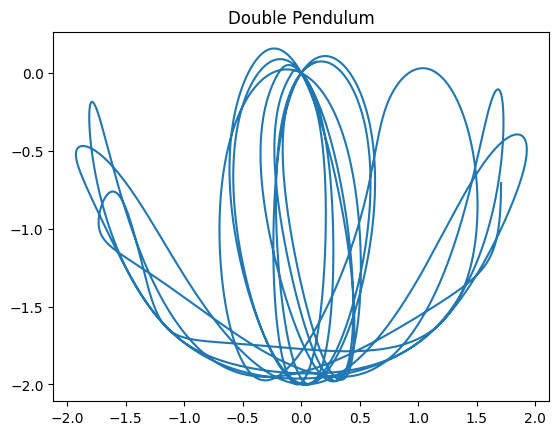

In [72]:

# 5. ODE Solver Function
def system(t, y, M1, M2, L1, L2, G):
    t1, w1, t2, w2 = y
    a1 = func1(t1, t2, w1, w2, M1, M2, L1, L2, G)
    a2 = func2(t1, t2, w1, w2, M1, M2, L1, L2, G)
    return [w1, a1, w2, a2]

# 6. Run Simulation
params = (1.0, 1.0, 1.0, 1.0, 9.81)
y0 = [np.pi/2, 0, np.pi/4, 0] # Start at 90 and 45 degrees
t_eval = np.linspace(0, 20, 1000000)

sol = solve_ivp(system, (0, 20), y0, t_eval=t_eval, args=params)

# 7. Plot results
x2_p = params[2]*np.sin(sol.y[0]) + params[3]*np.sin(sol.y[2])
y2_p = -params[2]*np.cos(sol.y[0]) - params[3]*np.cos(sol.y[2])

plt.plot(x2_p, y2_p)
plt.title("Double Pendulum")
plt.show()

In [73]:
import pandas as pd
import numpy as np

# 1. Define the Label (e.g., the specific simulation run)
run_label = "chaotic_swing_01"

# 2. Create the Base DataFrame from your ODE solver results
df = pd.DataFrame({
    # --- LABEL ---
    'label': run_label,
    
    # --- INPUT LAYER (Current State + Physics) ---
    'in_theta1': sol.y[0],
    'in_theta2': sol.y[2],
    'in_w1': sol.y[1],
    'in_w2': sol.y[3],
    'm1': params[0],
    'm2': params[1],
    'l1': params[2],
    'l2': params[3],
    'g': params[4],
})

# 3. Create the OUTPUT LAYER (The state at the NEXT timestep)
# We shift the columns back by 1 to align t with t+1
df['out_theta1'] = df['in_theta1'].shift(-1)
df['out_theta2'] = df['in_theta2'].shift(-1)
df['out_w1'] = df['in_w1'].shift(-1)
df['out_w2'] = df['in_w2'].shift(-1)

# 4. Clean up
# The last row will have NaNs for outputs (because there's no t+1), so we drop it
df = df.dropna()

# 5. Save to CSV
df.to_csv('pendulum_ml_data.csv', index=False)

# Show the structure
print("DataFrame columns categorized:")
print(f"Labels:  {['label']}")
print(f"Inputs:  {[col for col in df.columns if col.startswith('in_') or col in ['m1', 'm2', 'l1', 'l2', 'g']]}")
print(f"Outputs: {[col for col in df.columns if col.startswith('out_')]}")
df.head()

DataFrame columns categorized:
Labels:  ['label']
Inputs:  ['in_theta1', 'in_theta2', 'in_w1', 'in_w2', 'm1', 'm2', 'l1', 'l2', 'g']
Outputs: ['out_theta1', 'out_theta2', 'out_w1', 'out_w2']


,label,in_theta1,in_theta2,in_w1,in_w2,m1,m2,l1,l2,g,out_theta1,out_theta2,out_w1,out_w2
0,chaotic_swing_01,1.570796,0.785398,0.000000,0.000000e+00,1.0,1.0,1.0,1.0,9.81,1.570796,0.785398,-0.000196,3.629302e-13
1,chaotic_swing_01,1.570796,0.785398,-0.000196,3.629302e-13,1.0,1.0,1.0,1.0,9.81,1.570796,0.785398,-0.000392,2.903441e-12
2,chaotic_swing_01,1.570796,0.785398,-0.000392,2.903441e-12,1.0,1.0,1.0,1.0,9.81,1.570796,0.785398,-0.000589,9.799114e-12
3,chaotic_swing_01,1.570796,0.785398,-0.000589,9.799114e-12,1.0,1.0,1.0,1.0,9.81,1.570796,0.785398,-0.000785,2.322753e-11
4,chaotic_swing_01,1.570796,0.785398,-0.000785,2.322753e-11,1.0,1.0,1.0,1.0,9.81,1.570796,0.785398,-0.000981,4.536627e-11


In [74]:
import torch
import torch.nn as nn

# Assume 'df' is the DataFrame from the previous step
# Define exactly which columns are your "Inputs"
input_cols = ['in_theta1', 'in_theta2', 'in_w1', 'in_w2', 'm1', 'm2', 'l1', 'l2', 'g']
output_cols = ['out_theta1', 'out_theta2', 'out_w1', 'out_w2']

# Convert Pandas to PyTorch Tensors
X = torch.tensor(df[input_cols].values, dtype=torch.float32)
Y = torch.tensor(df[output_cols].values, dtype=torch.float32)

display(X)
display(Y)



tensor([[ 1.5708e+00,  7.8540e-01,  0.0000e+00,  ...,  1.0000e+00,
          1.0000e+00,  9.8100e+00],
        [ 1.5708e+00,  7.8540e-01, -1.9620e-04,  ...,  1.0000e+00,
          1.0000e+00,  9.8100e+00],
        [ 1.5708e+00,  7.8540e-01, -3.9240e-04,  ...,  1.0000e+00,
          1.0000e+00,  9.8100e+00],
        ...,
        [ 5.7907e-01, -4.6694e+01, -2.6013e+00,  ...,  1.0000e+00,
          1.0000e+00,  9.8100e+00],
        [ 5.7902e-01, -4.6694e+01, -2.6014e+00,  ...,  1.0000e+00,
          1.0000e+00,  9.8100e+00],
        [ 5.7897e-01, -4.6694e+01, -2.6015e+00,  ...,  1.0000e+00,
          1.0000e+00,  9.8100e+00]])

tensor([[ 1.5708e+00,  7.8540e-01, -1.9620e-04,  3.6293e-13],
        [ 1.5708e+00,  7.8540e-01, -3.9240e-04,  2.9034e-12],
        [ 1.5708e+00,  7.8540e-01, -5.8860e-04,  9.7991e-12],
        ...,
        [ 5.7902e-01, -4.6694e+01, -2.6014e+00, -4.5249e+00],
        [ 5.7897e-01, -4.6694e+01, -2.6015e+00, -4.5249e+00],
        [ 5.7892e-01, -4.6694e+01, -2.6016e+00, -4.5249e+00]])

In [75]:
# Simpe slicing for time-series consistency
split_idx = int(0.8 * len(X))
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = Y[:split_idx], Y[split_idx:]

In [76]:

import torch.optim as optim

# Define the architecture
class DoublePendulumNet(nn.Module):
    def __init__(self):
        super(DoublePendulumNet, self).__init__()
        # Input Layer: 9 -> 64 neurons
        self.fc1 = nn.Linear(9, 64)
        # Hidden Layer: 64 -> 64 neurons
        self.fc2 = nn.Linear(64, 64)
        # Output Layer: 64 -> 4 neurons (theta1, w1, theta2, w2)
        self.fc3 = nn.Linear(64, 4)
        
        self.relu = nn.ReLU() # Activation function

    def forward(self, x):
        # --- THE FEEDFORWARD PASS ---
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x) 
        return x

# Initialize model, loss function, and optimizer
model = DoublePendulumNet()
criterion = nn.MSELoss() # Mean Squared Error (Standard for regression)
optimizer = optim.Adam(model.parameters(), lr=0.001) # Adjusts weights


# Initialize lists to store losses
train_losses = []
test_losses = []

# Assuming X_train, y_train, X_test, y_test are your tensors
epochs = 2000

for epoch in range(epochs):
    # --- TRAINING PHASE ---
    model.train() # Set to training mode
    optimizer.zero_grad()
    
    # Forward pass
    predictions = model(X_train)
    loss = criterion(predictions, y_train)
    
    # Backward pass and optimization
    loss.backward()
    optimizer.step()
    
    # Store training loss
    train_losses.append(loss.item())
    
    # --- VALIDATION PHASE (Optional but recommended) ---
    model.eval()
    with torch.no_grad():
        test_preds = model(X_test)
        t_loss = criterion(test_preds, y_test)
        test_losses.append(t_loss.item())

    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {loss.item():.6e} | Test Loss: {t_loss.item():.6e}")

Epoch 20/2000 | Train Loss: 1.644548e+01 | Test Loss: 1.852106e+02
Epoch 40/2000 | Train Loss: 3.834012e+00 | Test Loss: 3.284744e+01
Epoch 60/2000 | Train Loss: 9.364698e-01 | Test Loss: 3.365362e+00
Epoch 80/2000 | Train Loss: 1.890206e-01 | Test Loss: 1.957741e+00
Epoch 100/2000 | Train Loss: 1.089253e-01 | Test Loss: 9.698887e-01
Epoch 120/2000 | Train Loss: 7.329959e-02 | Test Loss: 1.209648e+00
Epoch 140/2000 | Train Loss: 5.239172e-02 | Test Loss: 1.051321e+00
Epoch 160/2000 | Train Loss: 3.667963e-02 | Test Loss: 9.014205e-01
Epoch 180/2000 | Train Loss: 2.510662e-02 | Test Loss: 8.131055e-01
Epoch 200/2000 | Train Loss: 1.758724e-02 | Test Loss: 7.750828e-01
Epoch 220/2000 | Train Loss: 1.328800e-02 | Test Loss: 7.592544e-01
Epoch 240/2000 | Train Loss: 1.080678e-02 | Test Loss: 7.452983e-01
Epoch 260/2000 | Train Loss: 9.133860e-03 | Test Loss: 7.226878e-01
Epoch 280/2000 | Train Loss: 7.864765e-03 | Test Loss: 6.950539e-01
Epoch 300/2000 | Train Loss: 6.862123e-03 | Test Los

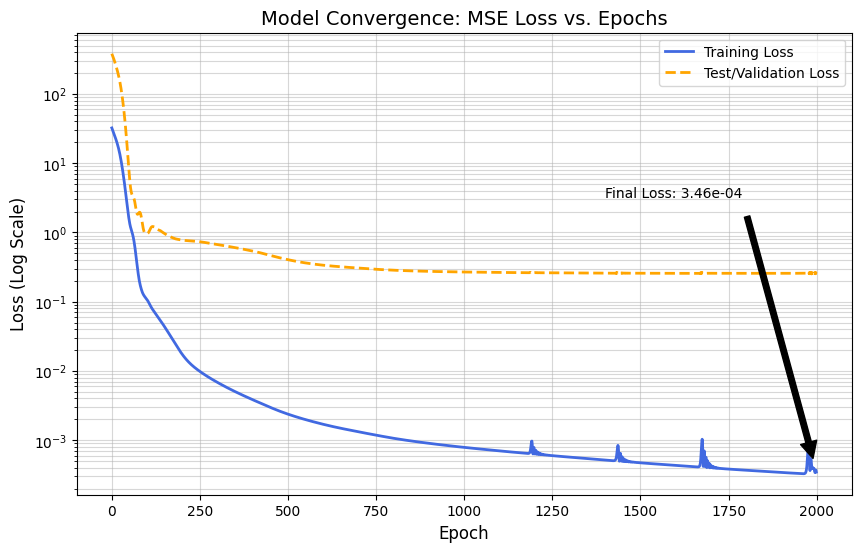

In [77]:
plt.figure(figsize=(10, 6))

# Plotting on a log scale is often better for MSE loss
plt.semilogy(train_losses, label='Training Loss', color='royalblue', lw=2)
plt.semilogy(test_losses, label='Test/Validation Loss', color='orange', linestyle='--', lw=2)

plt.title('Model Convergence: MSE Loss vs. Epochs', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss (Log Scale)', fontsize=12)
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.5)

# Highlight the final convergence point
plt.annotate(f'Final Loss: {train_losses[-1]:.2e}', 
             xy=(epochs, train_losses[-1]), 
             xytext=(epochs*0.7, train_losses[0]*0.1),
             arrowprops=dict(facecolor='black', shrink=0.05))

plt.show()
#validation needs to be as low as possible 

In [80]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# 1. Prepare the model for inference
model.eval() 

# 2. Set Initial Conditions (Start state)
# [theta1, theta2, w1, w2, m1, m2, l1, l2, g]
initial_state = [np.pi/2, np.pi/4, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 9.81]
current_input = torch.tensor([initial_state], dtype=torch.float32)

# 3. Recursive Simulation Loop
steps = 500
history = []

with torch.no_grad():
    for i in range(steps):
        # Store current state for plotting
        history.append(current_input.detach().cpu().numpy()[0])
        # PREDICT: The model outputs [out_theta1, out_theta2, out_w1, out_w2]
        prediction = model(current_input)
        
        # UPDATE: Construct the next input
        # We keep the physical constants (m, l, g) the same, 
        # but replace the angles and velocities with the model's output
        next_state = np.zeros(9)
        next_state[0:4] = prediction.numpy()[0] # Predicted state
        next_state[4:9] = initial_state[4:9]    # Keep m1, m2, l1, l2, g constant
        
        current_input = torch.tensor([next_state], dtype=torch.float32)

# 4. Convert history to a usable array
history = np.array(history)

Running Neural Simulation...


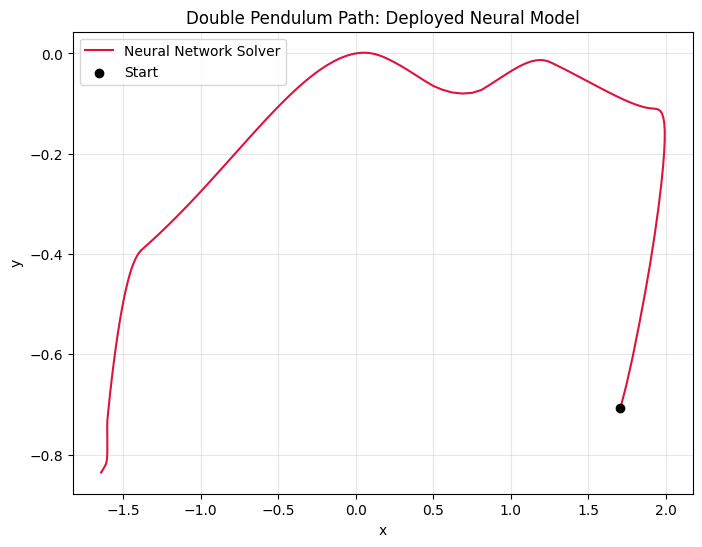

In [82]:

# 1. Setup Parameters (Match your training data constants)
M1, M2, L1, L2, G = 1.0, 1.0, 1.0, 1.0, 9.81
y0 = [np.pi/2, 0, np.pi/4, 0] # [theta1, w1, theta2, w2]
steps = 20000 # Number of recursive predictions
nn_history = []

# 2. Prepare the Model
model.eval()

# Initial Input state: [theta1, w1, theta2, w2, m1, m2, l1, l2, g]
# Ensure this matches the exact 9-column format we used for training
current_input = torch.tensor([[y0[0], y0[1], y0[2], y0[3], M1, M2, L1, L2, G]], dtype=torch.float32)

# 3. Recursive Prediction Loop
print("Running Neural Simulation...")
with torch.no_grad():
    for _ in range(steps):
        # Save the state for plotting (angles are index 0 and 2)
        state_array = current_input.cpu().numpy()[0]
        nn_history.append(state_array)
        
        # PREDICT: The model outputs the next [theta1, w1, theta2, w2]
        prediction = model(current_input)
        
        # UPDATE: Build the next input tensor
        # We take the 4 predicted values and re-append the 5 physical constants
        next_state = np.zeros((1, 9))
        next_state[0, 0:4] = prediction.numpy()[0]
        next_state[0, 4:9] = [M1, M2, L1, L2, G]
        
        current_input = torch.tensor(next_state, dtype=torch.float32)

# 4. Process Results
nn_history = np.array(nn_history)
theta1_nn = nn_history[:, 0]
theta2_nn = nn_history[:, 2]

# 5. Convert to Cartesian Coordinates for the second bob
x2_nn = L1 * np.sin(theta1_nn) + L2 * np.sin(theta2_nn)
y2_nn = -L1 * np.cos(theta1_nn) - L2 * np.cos(theta2_nn)

# 6. Plot the AI's Trajectory
plt.figure(figsize=(8, 6))
plt.plot(x2_nn, y2_nn, label='Neural Network Solver', color='crimson', lw=1.5)
plt.scatter(x2_nn[0], y2_nn[0], color='black', zorder=5, label='Start') # Start point
plt.title("Double Pendulum Path: Deployed Neural Model")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(alpha=0.3)
plt.show()